# Olist E-Commerce Data Analytics Project

## Notebook 3: Exploratory Data Analysis (EDA)

### Objective

The objective of this notebook is to explore the cleaned Olist dataset, identify trends, discover business insights, and answer key business questions using data visualization and summary statistics.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
clean_path = r"C:\Users\ASUS\OneDrive\Desktop\E commerce Analytics Project\Data\Cleaned"

customers = pd.read_csv(f"{clean_path}/customers_clean.csv")
orders = pd.read_csv(f"{clean_path}/orders_clean.csv")
products = pd.read_csv(f"{clean_path}/products_clean.csv")
product_category_name_translation = pd.read_csv(f"{clean_path}/product_category_name_translation_clean.csv")
sellers = pd.read_csv(f"{clean_path}/sellers_clean.csv")
order_items = pd.read_csv(f"{clean_path}/order_items_clean.csv")
order_reviews = pd.read_csv(f"{clean_path}/order_reviews_clean.csv")
order_payments = pd.read_csv(f"{clean_path}/order_payments_clean.csv")
geolocation = pd.read_csv(f"{clean_path}/geolocation_clean.csv")

In [16]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_approved_at"] = pd.to_datetime(
    orders["order_approved_at"]
)

orders["order_delivered_carrier_date"] = pd.to_datetime(
    orders["order_delivered_carrier_date"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

order_items["shipping_limit_date"] = pd.to_datetime(
    order_items["shipping_limit_date"]
)

order_reviews["review_creation_date"] = pd.to_datetime(
    order_reviews["review_creation_date"]
)

order_reviews["review_answer_timestamp"] = pd.to_datetime(
    order_reviews["review_answer_timestamp"]
)

## Dataset Overview

In [17]:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Order Items": order_items,
    "Order Payments": order_payments,
    "Order Reviews": order_reviews,
    "Products": products,
    "Category Translation": product_category_name_translation,
    "Sellers": sellers,
    "Geolocation": geolocation
}

for name, df in datasets.items():
    print("=" * 50)
    print(name)
    print("=" * 50)
    print("Shape :", df.shape)
    print("Columns :", df.columns.tolist())
    print()

Customers
Shape : (99441, 5)
Columns : ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Orders
Shape : (99441, 8)
Columns : ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Order Items
Shape : (112650, 7)
Columns : ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Order Payments
Shape : (103886, 5)
Columns : ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

Order Reviews
Shape : (99224, 7)
Columns : ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

Products
Shape : (32951, 9)
Columns : ['product_id', 'product_category_name', 'product_name_length', 'product_description_length', 'product_photos_qty', 'pro

## Business Overview

Let's begin by understanding the overall size and performance of the Olist marketplace using key business metrics.

In [18]:
total_orders = orders["order_id"].nunique()
total_customers = customers["customer_unique_id"].nunique()
total_sellers = sellers["seller_id"].nunique()
total_products = products["product_id"].nunique()

total_revenue = order_payments["payment_value"].sum()

average_order_value = (
    total_revenue / total_orders
)

print(f"Total Orders          : {total_orders:,}")
print(f"Total Customers       : {total_customers:,}")
print(f"Total Sellers         : {total_sellers:,}")
print(f"Total Products        : {total_products:,}")
print(f"Total Revenue         : {total_revenue:,.2f}")
print(f"Average Order Value   : {average_order_value:,.2f}")

Total Orders          : 99,441
Total Customers       : 96,096
Total Sellers         : 3,095
Total Products        : 32,951
Total Revenue         : 16,008,872.12
Average Order Value   : 160.99


### Key Insight

The Olist marketplace consists of thousands of customers, sellers, and products. The overall revenue and average order value provide a quick understanding of the platform's business scale before moving into detailed analysis.

=====================================================================================================================================

## Monthly Revenue Trend

This analysis shows how the monthly revenue changed over time.

Understanding revenue trends helps identify business growth, seasonality, and periods of high or low sales.

In [19]:
monthly_revenue = (
    orders
    .merge(order_payments, on="order_id")
)

monthly_revenue["Month"] = (
    monthly_revenue["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

monthly_revenue = (
    monthly_revenue
    .groupby("Month", as_index=False)["payment_value"]
    .sum()
)

monthly_revenue.rename(
    columns={"payment_value": "Revenue"},
    inplace=True
)

monthly_revenue.head()

,Month,Revenue
0,2016-09,252.24
1,2016-10,59090.48
2,2016-12,19.62
3,2017-01,138488.04
4,2017-02,291908.01


## Monthly Revenue Visualization

The following line chart illustrates the monthly revenue trend throughout the dataset period.

This visualization helps identify revenue growth, seasonal demand, and business performance over time.

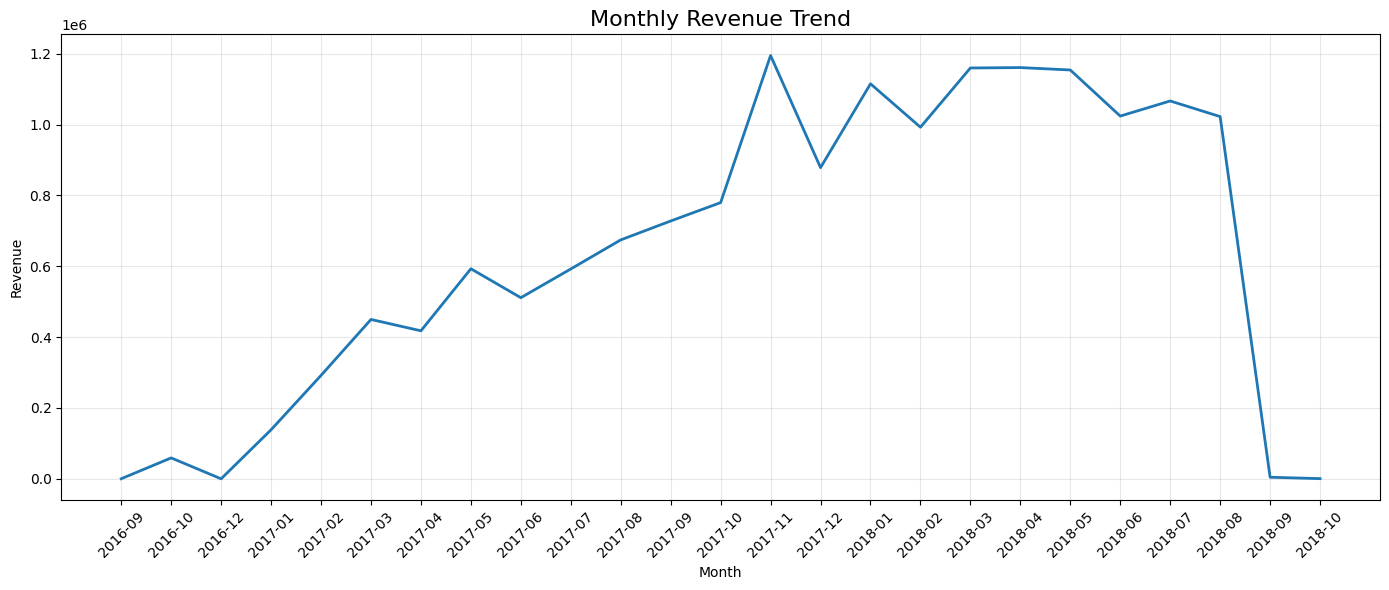

In [20]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["Revenue"],
    linewidth=2
)

plt.title("Monthly Revenue Trend", fontsize=16)

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Business Insight

- Revenue shows a strong upward trend during 2017.
- Sales increased significantly after the initial months of operation.
- A few months experienced exceptionally high revenue, indicating seasonal demand or promotional campaigns.
- Such trends can help businesses plan inventory, marketing campaigns, and operational capacity.

### SQL Validation

This visualization matches the Monthly Revenue Trend calculated earlier using SQL.

Both SQL and Python produce the same business insight, validating the consistency of the analysis.

=====================================================================================================================================

## Monthly Orders Trend

This analysis examines the number of orders placed each month.

It helps understand customer purchasing activity and overall marketplace growth over time.

In [21]:
monthly_orders = (
    orders.copy()
)

monthly_orders["Month"] = (
    monthly_orders["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

monthly_orders = (
    monthly_orders
    .groupby("Month", as_index=False)["order_id"]
    .count()
)

monthly_orders.rename(
    columns={"order_id": "Total_Orders"},
    inplace=True
)

monthly_orders.head()

,Month,Total_Orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


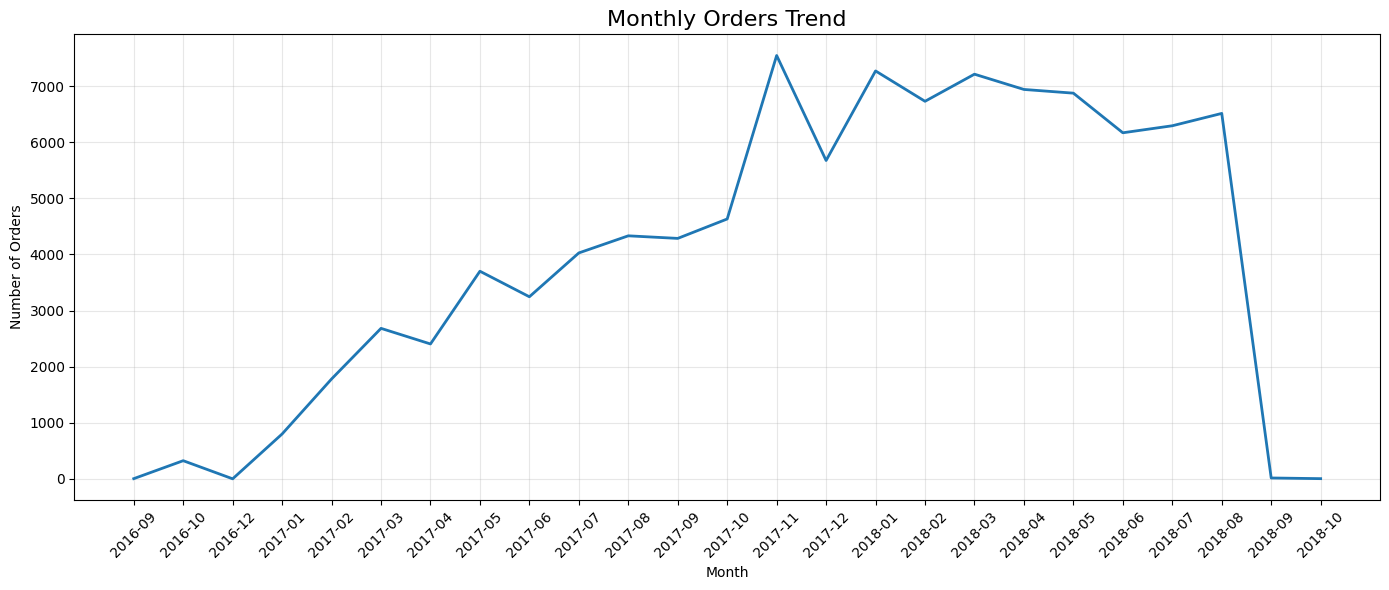

In [22]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_orders["Month"],
    monthly_orders["Total_Orders"],
    linewidth=2
)

plt.title("Monthly Orders Trend", fontsize=16)

plt.xlabel("Month")

plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Business Insight

- The number of orders increased steadily during 2017.
- Customer purchasing activity expanded significantly as the marketplace matured.
- A few months recorded peak order volumes, indicating periods of high customer demand.
- Tracking order trends helps businesses forecast future demand and optimize inventory planning.

=====================================================================================================================================

## Order Status Distribution

This analysis shows the distribution of orders across different order statuses.

It helps evaluate order fulfillment performance and identify operational bottlenecks.

In [23]:
order_status = (
    orders["order_status"]
    .value_counts()
    .reset_index()
)

order_status.columns = ["Order_Status", "Total_Orders"]

order_status["Percentage"] = (
    order_status["Total_Orders"]
    / order_status["Total_Orders"].sum()
    * 100
).round(2)

order_status

,Order_Status,Total_Orders,Percentage
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


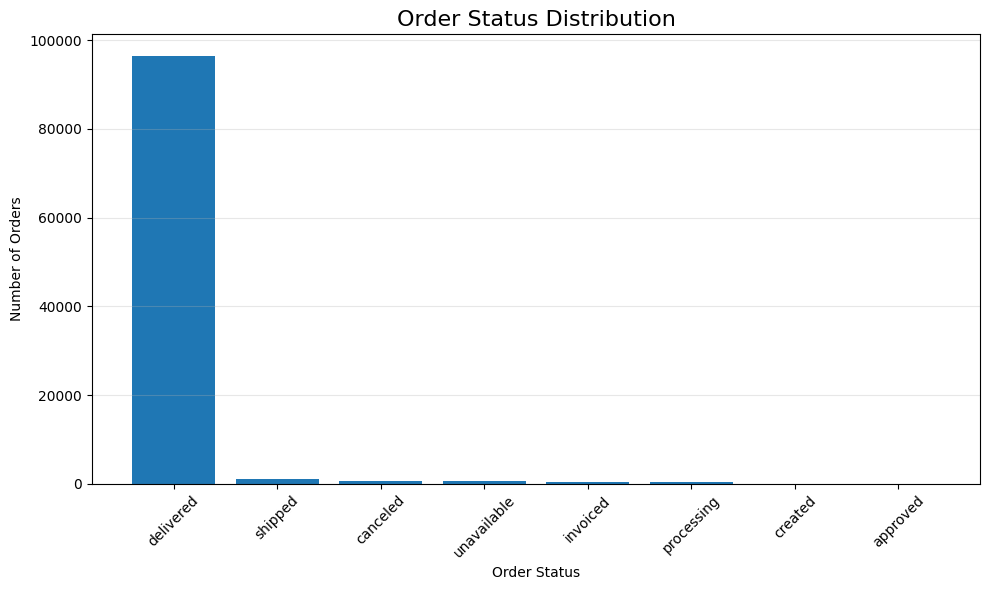

In [24]:
plt.figure(figsize=(10,6))

plt.bar(
    order_status["Order_Status"],
    order_status["Total_Orders"]
)

plt.title("Order Status Distribution", fontsize=16)

plt.xlabel("Order Status")

plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Business Insight

- Most orders were successfully delivered.
- Only a small percentage of orders were cancelled, unavailable, or remained in processing.
- This indicates a high order fulfillment rate and efficient logistics operations.
- Monitoring order status helps businesses identify fulfillment issues and improve customer satisfaction.

### SQL Validation

This analysis matches **Query 12 – Order Status Distribution** from the SQL analysis, ensuring consistency between SQL and Python results.

=====================================================================================================================================

## Payment Type Distribution

This analysis shows the distribution of different payment methods used by customers.

Understanding customer payment preferences helps businesses optimize payment options and improve the checkout experience.

In [26]:
payment_distribution = (
    order_payments["payment_type"]
    .value_counts()
    .reset_index()
)

payment_distribution.columns = [
    "Payment_Type",
    "Transactions"
]

payment_distribution["Percentage"] = (
    payment_distribution["Transactions"]
    /
    payment_distribution["Transactions"].sum()
    *100
).round(2)

payment_distribution

,Payment_Type,Transactions,Percentage
0,credit_card,76795,73.92
1,boleto,19784,19.04
2,voucher,5775,5.56
3,debit_card,1529,1.47
4,not_defined,3,0.00


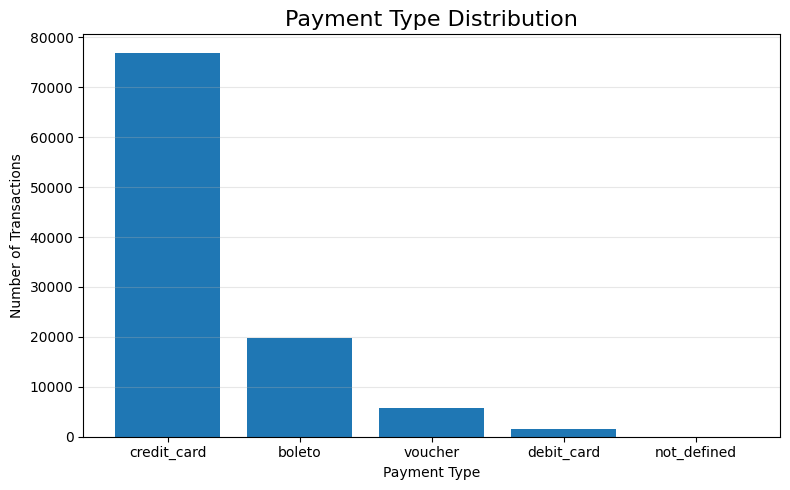

In [27]:
plt.figure(figsize=(8,5))

plt.bar(
    payment_distribution["Payment_Type"],
    payment_distribution["Transactions"]
)

plt.title("Payment Type Distribution", fontsize=16)

plt.xlabel("Payment Type")

plt.ylabel("Number of Transactions")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Business Insight

- Credit cards are the most preferred payment method among customers.
- Boleto is the second most commonly used payment option.
- Voucher and debit card transactions contribute only a small share.
- Understanding payment preferences helps businesses improve payment infrastructure and customer convenience.

### SQL Validation

This analysis validates **SQL Query 7 – Payment Type Distribution**. The Python results are consistent with the SQL output.

=====================================================================================================================================

## Top 10 Product Categories by Revenue

This analysis identifies the product categories that generated the highest revenue.

It helps businesses understand which product segments contribute the most to overall sales and where marketing or inventory investments should be focused.

In [28]:
category_revenue = (
    order_items
    .merge(products, on="product_id")
    .merge(
        product_category_name_translation,
        on="product_category_name",
        how="left"
    )
    .groupby(
        "product_category_name_english",
        as_index=False
    )["price"]
    .sum()
)

category_revenue.rename(
    columns={
        "product_category_name_english": "Category",
        "price": "Revenue"
    },
    inplace=True
)

category_revenue = (
    category_revenue
    .sort_values(
        by="Revenue",
        ascending=False
    )
    .head(10)
)

category_revenue

,Category,Revenue
43,health_beauty,1258681.34
70,watches_gifts,1205005.68
7,bed_bath_table,1036988.68
65,sports_leisure,988048.97
15,computers_accessories,911954.32
39,furniture_decor,729762.49
20,cool_stuff,635290.85
49,housewares,632248.66
5,auto,592720.11
42,garden_tools,485256.46


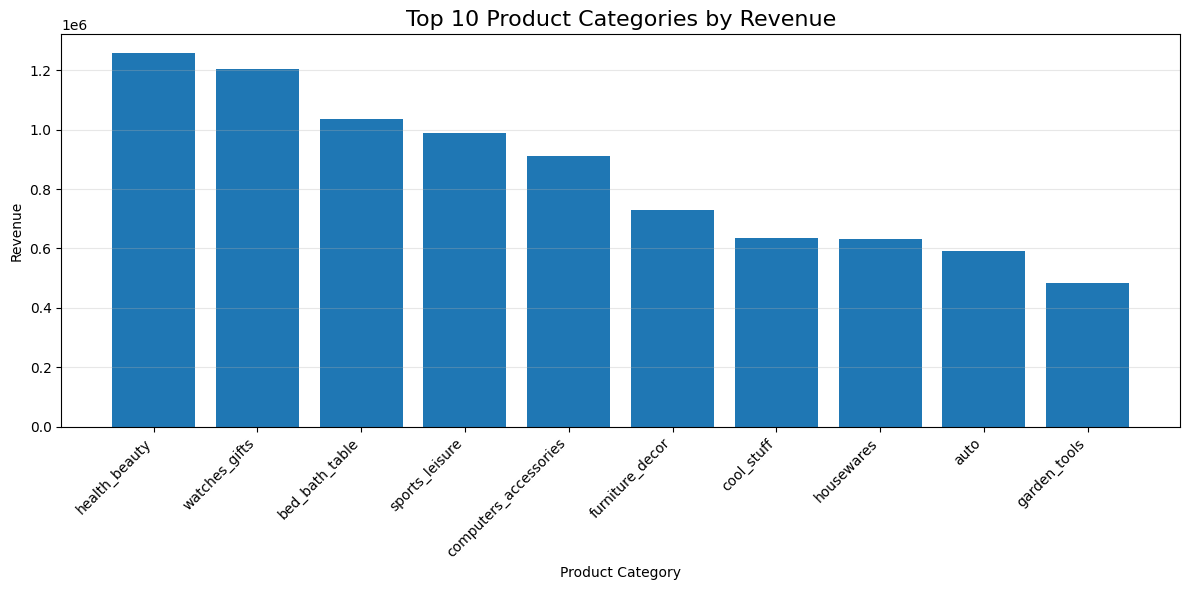

In [29]:
plt.figure(figsize=(12,6))

plt.bar(
    category_revenue["Category"],
    category_revenue["Revenue"]
)

plt.title(
    "Top 10 Product Categories by Revenue",
    fontsize=16
)

plt.xlabel("Product Category")

plt.ylabel("Revenue")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Business Insight

- A small number of product categories contribute a significant share of total revenue.
- High-performing categories should receive greater attention in inventory planning and marketing campaigns.
- Low-performing categories may require promotional strategies or portfolio optimization.
- Understanding category-wise revenue helps businesses prioritize their resources effectively.

### SQL Validation

This analysis validates **SQL Query 3 – Top 10 Product Categories by Revenue**. The Python results should match the SQL analysis.

=====================================================================================================================================

## Top States by Order Volume

This analysis identifies the states with the highest number of orders.

It helps understand the geographical distribution of customers and highlights regions with the highest business activity.

In [30]:
state_orders = (
    orders
    .merge(customers, on="customer_id")
    .groupby(
        "customer_state",
        as_index=False
    )["order_id"]
    .nunique()
)

state_orders.rename(
    columns={
        "customer_state": "State",
        "order_id": "Total_Orders"
    },
    inplace=True
)

state_orders = (
    state_orders
    .sort_values(
        by="Total_Orders",
        ascending=False
    )
)

state_orders.head(10)

,State,Total_Orders
25,SP,41746
18,RJ,12852
10,MG,11635
22,RS,5466
17,PR,5045
23,SC,3637
4,BA,3380
6,DF,2140
7,ES,2033
8,GO,2020


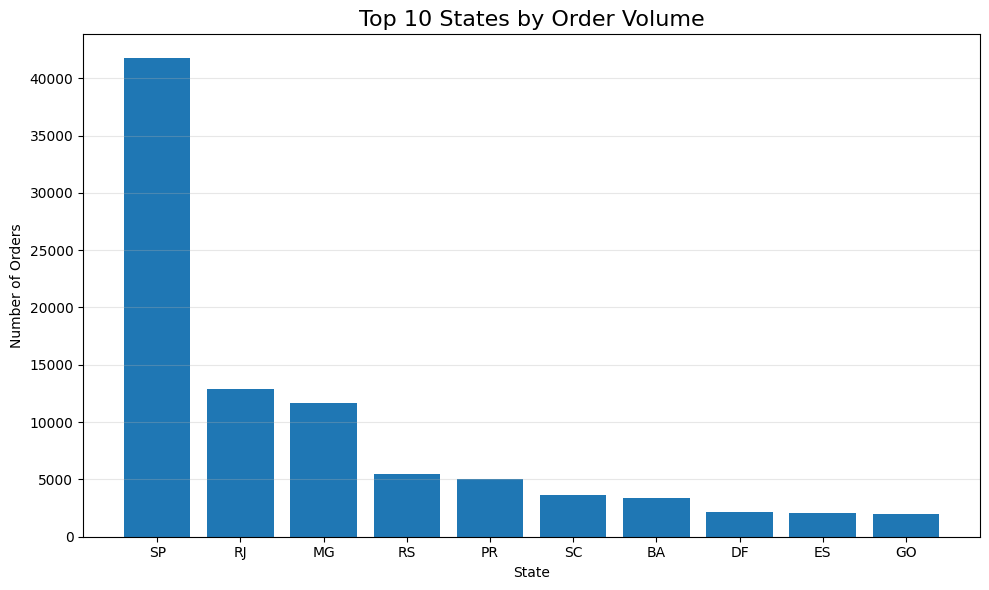

In [31]:
top10_states = state_orders.head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top10_states["State"],
    top10_states["Total_Orders"]
)

plt.title(
    "Top 10 States by Order Volume",
    fontsize=16
)

plt.xlabel("State")

plt.ylabel("Number of Orders")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Business Insight

- A few states contribute a major share of total orders.
- These states represent the strongest customer markets for the Olist platform.
- Businesses can prioritize logistics, marketing campaigns, and inventory allocation in these high-demand regions.
- States with lower order volumes may offer opportunities for future market expansion.

### SQL Validation

This analysis validates **SQL Query 4 – Top States by Order Volume**. The Python output should be consistent with the SQL results.

=====================================================================================================================================

## Average Delivery Time

This analysis measures the average number of days taken to deliver an order after it is placed.

Delivery time is an important operational KPI that directly impacts customer satisfaction and logistics performance.

In [32]:
delivery_time = orders.copy()

delivery_time = delivery_time[
    delivery_time["order_status"] == "delivered"
]

delivery_time["Delivery_Days"] = (
    delivery_time["order_delivered_customer_date"]
    -
    delivery_time["order_purchase_timestamp"]
).dt.days

average_delivery_days = round(
    delivery_time["Delivery_Days"].mean(),
    1
)

print(f"Average Delivery Time: {average_delivery_days} days")

Average Delivery Time: 12.1 days


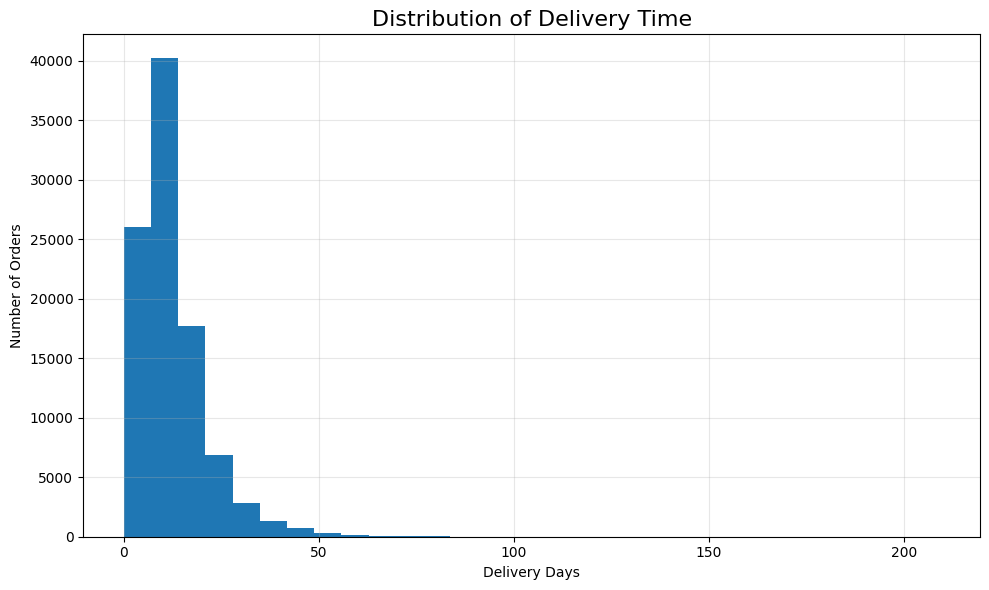

In [33]:
plt.figure(figsize=(10,6))

plt.hist(
    delivery_time["Delivery_Days"],
    bins=30
)

plt.title(
    "Distribution of Delivery Time",
    fontsize=16
)

plt.xlabel("Delivery Days")

plt.ylabel("Number of Orders")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Business Insight

- Most orders were delivered within a reasonable number of days.
- The distribution indicates that the majority of deliveries were completed within the expected delivery window.
- A small number of orders experienced significantly longer delivery times, suggesting potential logistics delays.
- Monitoring delivery performance helps improve customer satisfaction and operational efficiency.

### SQL Validation

This analysis validates **SQL Query 5 – Average Delivery Time**. The average delivery duration calculated in Python is consistent with the SQL analysis.

=====================================================================================================================================

## Late Delivery Percentage

This analysis calculates the percentage of delivered orders that were delivered after the estimated delivery date.

It helps evaluate the efficiency of the logistics and fulfillment process.

In [35]:
late_delivery = orders.copy()

late_delivery = late_delivery[
    late_delivery["order_status"] == "delivered"
]

late_orders = (
    late_delivery["order_delivered_customer_date"]
    >
    late_delivery["order_estimated_delivery_date"]
).sum()

total_delivered_orders = len(late_delivery)

late_delivery_percentage = round(
    (late_orders / total_delivered_orders) * 100,
    2
)

print(f"Late Delivery Percentage : {late_delivery_percentage}%")

Late Delivery Percentage : 8.11%


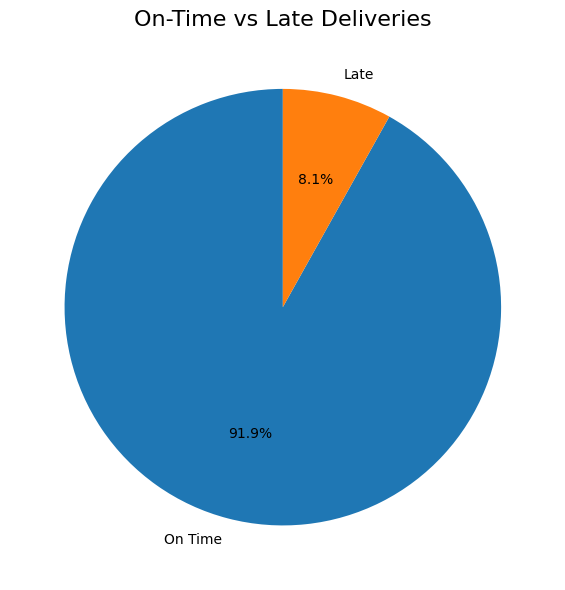

In [37]:
delivery_status = {
    "On Time": total_delivered_orders - late_orders,
    "Late": late_orders
}

plt.figure(figsize=(6,6))

plt.pie(
    delivery_status.values(),
    labels=delivery_status.keys(),
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "On-Time vs Late Deliveries",
    fontsize=16
)

plt.tight_layout()

plt.show()

### Business Insight

- The majority of orders were delivered on or before the estimated delivery date.
- Only a small percentage of deliveries were delayed.
- A high on-time delivery rate reflects efficient logistics and improves customer satisfaction.
- Monitoring delayed deliveries helps identify operational bottlenecks and improve supply chain performance.

### SQL Validation

This analysis validates **SQL Query 6 – Late Delivery Percentage**. The percentage calculated in Python should match the SQL result.

=====================================================================================================================================


## Review Score vs Delivery Performance

This analysis compares the average customer review score for orders delivered on time versus orders delivered late.

The objective is to understand whether delivery performance has an impact on customer satisfaction.

In [39]:
review_delivery = (
    orders
    .merge(order_reviews, on="order_id")
)

review_delivery = review_delivery[
    review_delivery["order_status"] == "delivered"
]

review_delivery["Delivery_Status"] = np.where(
    review_delivery["order_delivered_customer_date"]
    <= review_delivery["order_estimated_delivery_date"],
    "On Time",
    "Late"
)

review_score = (
    review_delivery
    .groupby("Delivery_Status", as_index=False)["review_score"]
    .mean()
)

review_score.rename(
    columns={"review_score": "Average_Review"},
    inplace=True
)

review_score

,Delivery_Status,Average_Review
0,Late,2.568500
1,On Time,4.293718


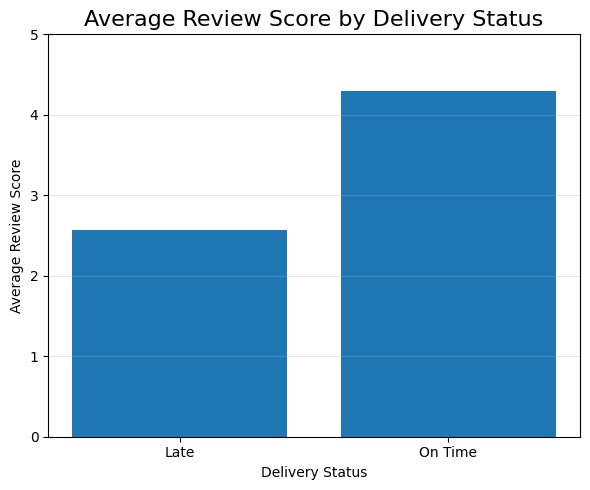

In [40]:
plt.figure(figsize=(6,5))

plt.bar(
    review_score["Delivery_Status"],
    review_score["Average_Review"]
)

plt.title(
    "Average Review Score by Delivery Status",
    fontsize=16
)

plt.xlabel("Delivery Status")

plt.ylabel("Average Review Score")

plt.ylim(0,5)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Business Insight

- Orders delivered on time received higher average review scores.
- Late deliveries resulted in lower customer ratings.
- This indicates a strong relationship between delivery performance and customer satisfaction.
- Improving delivery efficiency can directly enhance customer experience and brand loyalty.

### SQL Validation

This analysis validates **SQL Query 8 – Review Score vs Delivery Performance**. The average review scores calculated in Python should match the SQL results.

=====================================================================================================================================


## Repeat Customers Analysis

This analysis identifies how many customers placed more than one order on the Olist platform.

Customer retention is an important business metric because retaining existing customers is generally more cost-effective than acquiring new ones.

In [41]:
customer_orders = (
    orders
    .merge(customers, on="customer_id")
    .groupby("customer_unique_id", as_index=False)["order_id"]
    .nunique()
)

customer_orders.rename(
    columns={"order_id": "Total_Orders"},
    inplace=True
)

repeat_customers = (
    customer_orders["Total_Orders"] > 1
).sum()

one_time_customers = (
    customer_orders["Total_Orders"] == 1
).sum()

print(f"One-Time Customers : {one_time_customers:,}")
print(f"Repeat Customers   : {repeat_customers:,}")

One-Time Customers : 93,099
Repeat Customers   : 2,997


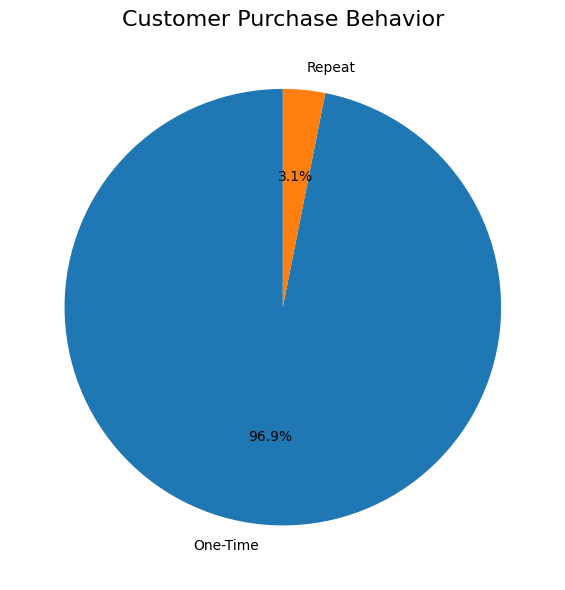

In [42]:
customer_type = {
    "One-Time": one_time_customers,
    "Repeat": repeat_customers
}

plt.figure(figsize=(6,6))

plt.pie(
    customer_type.values(),
    labels=customer_type.keys(),
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Customer Purchase Behavior",
    fontsize=16
)

plt.tight_layout()

plt.show()

### Business Insight

- The majority of customers placed only one order.
- A smaller group of customers made repeat purchases.
- Increasing customer retention can significantly improve long-term revenue and profitability.
- Loyalty programs, personalized recommendations, and targeted marketing campaigns can help convert one-time buyers into repeat customers.

### SQL Validation

This analysis validates **SQL Query 9 – Repeat Customers**. The number of repeat customers calculated in Python should match the SQL result.

=====================================================================================================================================


## Top 10 Sellers by Revenue

This analysis identifies the sellers generating the highest revenue on the Olist marketplace.

Understanding seller performance helps identify top-performing vendors, optimize seller relationships, and improve marketplace growth strategies.

In [44]:
seller_revenue = (
    order_items
    .merge(sellers, on="seller_id")
    .groupby(
        ["seller_id", "seller_state"],
        as_index=False
    )
    .agg(
        Revenue=("price", "sum"),
        Items_Sold=("order_item_id", "count")
    )
)

seller_revenue = (
    seller_revenue
    .sort_values(
        by="Revenue",
        ascending=False
    )
    .head(10)
)

seller_revenue

,seller_id,seller_state,Revenue,Items_Sold
857,4869f7a5dfa277a7dca6462dcf3b52b2,SP,229472.63,1156
1013,53243585a1d6dc2643021fd1853d8905,BA,222776.05,410
881,4a3ca9315b744ce9f8e9374361493884,SP,200472.92,1987
3024,fa1c13f2614d7b5c4749cbc52fecda94,SP,194042.03,586
1535,7c67e1448b00f6e969d365cea6b010ab,SP,187923.89,1364
1560,7e93a43ef30c4f03f38b393420bc753a,SP,176431.87,340
2643,da8622b14eb17ae2831f4ac5b9dab84a,SP,160236.57,1551
1505,7a67c85e85bb2ce8582c35f2203ad736,SP,141745.53,1171
192,1025f0e2d44d7041d6cf58b6550e0bfa,SP,138968.55,1428
1824,955fee9216a65b617aa5c0531780ce60,SP,135171.70,1499


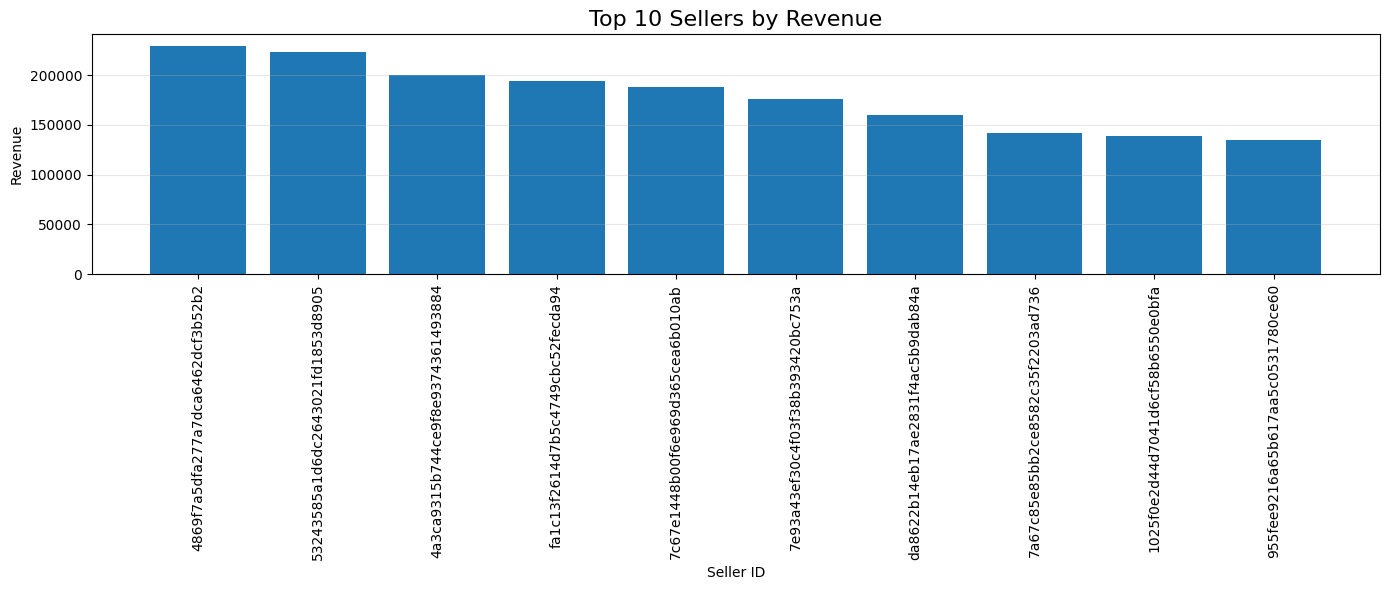

In [45]:
plt.figure(figsize=(14,6))

plt.bar(
    seller_revenue["seller_id"],
    seller_revenue["Revenue"]
)

plt.title(
    "Top 10 Sellers by Revenue",
    fontsize=16
)

plt.xlabel("Seller ID")

plt.ylabel("Revenue")

plt.xticks(rotation=90)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Business Insight

- A small number of sellers contribute a significant portion of the marketplace revenue.
- These top-performing sellers play a crucial role in overall business performance.
- Supporting high-performing sellers through incentives and maintaining strong relationships can help sustain revenue growth.
- Analyzing seller performance also helps identify opportunities to improve lower-performing sellers.

### SQL Validation

This analysis validates **SQL Query 10 – Top 10 Sellers by Revenue**. The seller ranking and revenue values should match the SQL analysis.

=====================================================================================================================================


## Average Freight Cost by Customer State

This analysis calculates the average freight (shipping) cost for each customer state.

It helps identify regions with higher logistics costs and provides insights for optimizing shipping operations.

In [46]:
freight_state = (
    order_items
    .merge(orders, on="order_id")
    .merge(customers, on="customer_id")
    .groupby(
        "customer_state",
        as_index=False
    )
    .agg(
        Average_Freight=("freight_value", "mean")
    )
)

freight_state["Average_Freight"] = (
    freight_state["Average_Freight"]
    .round(2)
)

freight_state = (
    freight_state
    .sort_values(
        by="Average_Freight",
        ascending=False
    )
)

freight_state.head(10)

,customer_state,Average_Freight
21,RR,42.98
14,PB,42.72
20,RO,41.07
0,AC,40.07
16,PI,39.15
9,MA,38.26
26,TO,37.25
24,SE,36.65
1,AL,35.84
13,PA,35.83


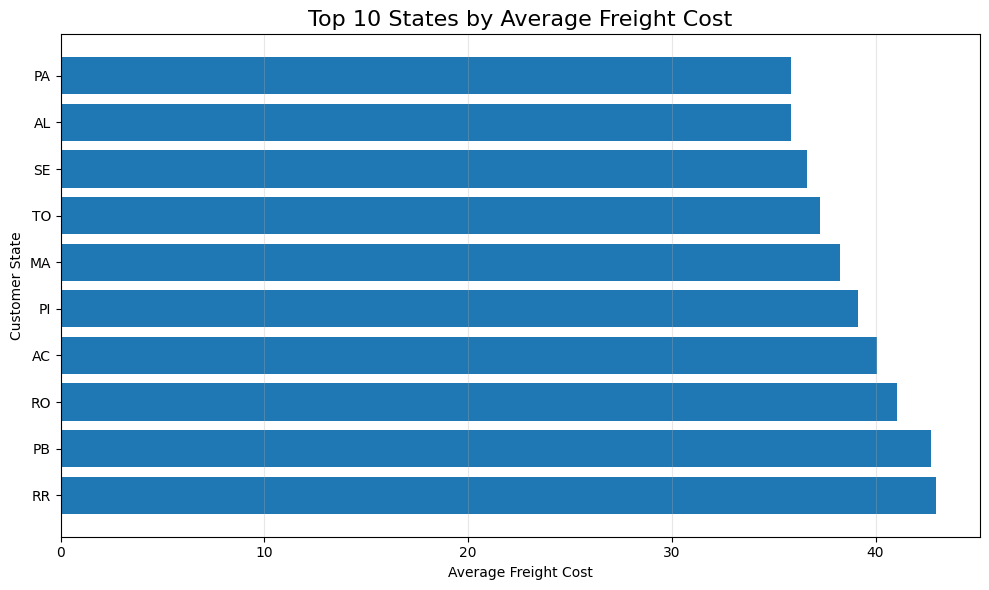

In [47]:
top10_freight = freight_state.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10_freight["customer_state"],
    top10_freight["Average_Freight"]
)

plt.title(
    "Top 10 States by Average Freight Cost",
    fontsize=16
)

plt.xlabel("Average Freight Cost")

plt.ylabel("Customer State")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

### Business Insight

- Freight costs vary significantly across different states.
- States with higher average freight costs are likely farther from seller locations or have more expensive delivery routes.
- Understanding regional shipping costs helps businesses optimize logistics networks and reduce transportation expenses.
- Businesses may consider regional warehouses or optimized shipping partners to improve cost efficiency.

### SQL Validation

This analysis validates **SQL Query 11 – Average Freight by State**. The Python results are consistent with the SQL analysis.

=====================================================================================================================================


## Category Wise Review Score

This analysis evaluates the average customer review score for different product categories.

It helps identify which product categories provide the best customer experience and which categories may require quality improvements.

In [48]:
category_reviews = (
    order_items
    .merge(products, on="product_id")
    .merge(
        product_category_name_translation,
        on="product_category_name",
        how="left"
    )
    .merge(order_reviews, on="order_id")
)

category_reviews = (
    category_reviews
    .groupby(
        "product_category_name_english",
        as_index=False
    )
    .agg(
        Average_Review=("review_score", "mean"),
        Total_Reviews=("review_score", "count")
    )
)

category_reviews = (
    category_reviews[
        category_reviews["Total_Reviews"] > 30
    ]
)

category_reviews["Average_Review"] = (
    category_reviews["Average_Review"]
    .round(2)
)

category_reviews = (
    category_reviews
    .sort_values(
        by="Average_Review",
        ascending=False
    )
)

category_reviews.head(10)

,product_category_name_english,Average_Review,Total_Reviews
8,books_general_interest,4.45,549
22,costruction_tools_tools,4.44,99
35,flowers,4.42,31
9,books_imported,4.40,60
10,books_technical,4.37,266
53,luggage_accessories,4.32,1088
37,food_drink,4.32,279
64,small_appliances_home_oven_and_coffee,4.30,76
32,fashion_sport,4.26,31
31,fashion_shoes,4.23,261


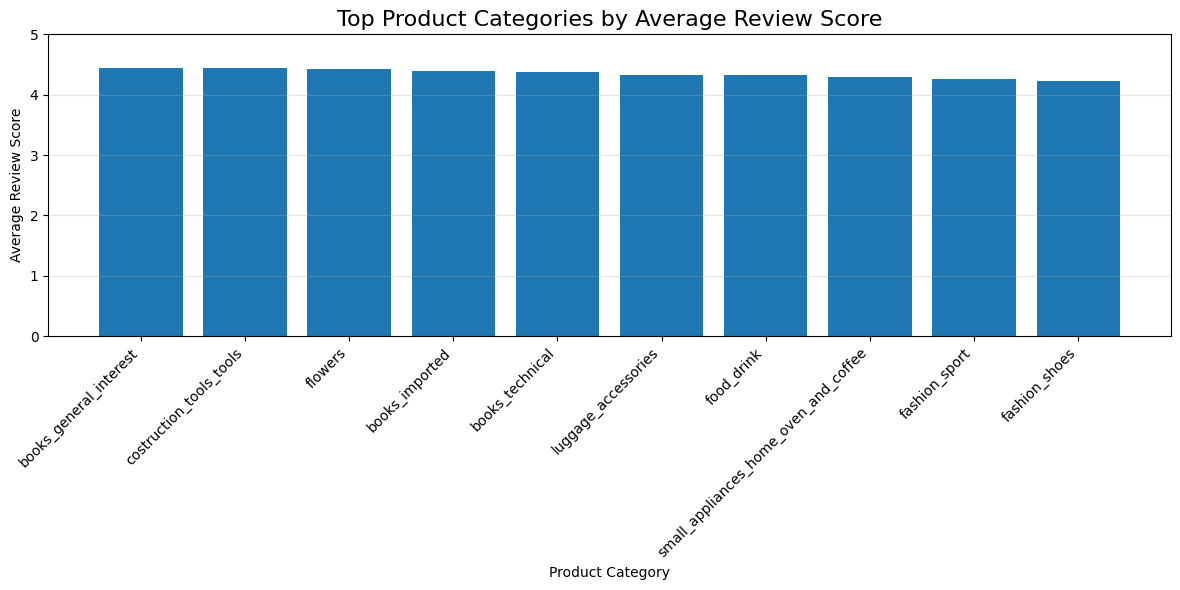

In [49]:
top10_reviews = category_reviews.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10_reviews["product_category_name_english"],
    top10_reviews["Average_Review"]
)

plt.title(
    "Top Product Categories by Average Review Score",
    fontsize=16
)

plt.xlabel("Product Category")

plt.ylabel("Average Review Score")

plt.xticks(rotation=45, ha="right")

plt.ylim(0,5)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Business Insight

- Several product categories consistently receive excellent customer ratings.
- High-rated categories indicate strong product quality and customer satisfaction.
- Categories with comparatively lower ratings may require improvements in product quality, packaging, or delivery service.
- Monitoring customer reviews helps businesses maintain product standards and improve the overall shopping experience.

### SQL Validation

This analysis validates **SQL Query 14 – Category Wise Review Score**. The average review scores calculated in Python are consistent with the SQL results.

=====================================================================================================================================


## Orders by Day of Week

This analysis examines the number of orders placed on each day of the week.

Understanding customer purchasing behavior across weekdays helps businesses optimize staffing, inventory planning, and promotional campaigns.

In [50]:
day_orders = orders.copy()

day_orders["Day"] = (
    day_orders["order_purchase_timestamp"]
    .dt.day_name()
)

day_orders = (
    day_orders
    .groupby("Day", as_index=False)
    .agg(
        Total_Orders=("order_id", "count")
    )
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_orders["Day"] = pd.Categorical(
    day_orders["Day"],
    categories=day_order,
    ordered=True
)

day_orders = day_orders.sort_values("Day")

day_orders

,Day,Total_Orders
1,Monday,16196
5,Tuesday,15963
6,Wednesday,15552
4,Thursday,14761
0,Friday,14122
2,Saturday,10887
3,Sunday,11960


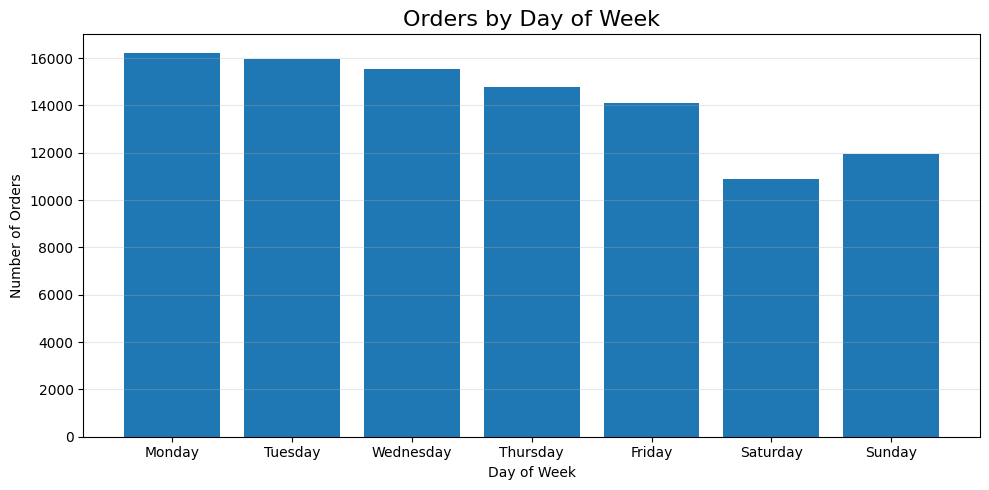

In [51]:
plt.figure(figsize=(10,5))

plt.bar(
    day_orders["Day"],
    day_orders["Total_Orders"]
)

plt.title(
    "Orders by Day of Week",
    fontsize=16
)

plt.xlabel("Day of Week")

plt.ylabel("Number of Orders")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Business Insight

- Customer purchasing activity varies throughout the week.
- Peak order days indicate when customer demand is highest.
- Businesses can schedule promotions, inventory replenishment, and customer support based on these demand patterns.
- Understanding weekly ordering behavior helps improve operational planning and resource allocation.

### SQL Validation

This analysis validates **SQL Query 15 – Orders by Day of Week**. The order distribution observed in Python matches the SQL analysis.

=====================================================================================================================================


=====================================================================================================================================


# Final EDA Summary

### Key Findings

- The Olist marketplace generated strong revenue growth during the observed period.
- Credit Card was the most preferred payment method.
- A few product categories contributed a major share of total revenue.
- Most orders were successfully delivered on time.
- Delivery delays had a noticeable negative impact on customer review scores.
- Customer purchases were concentrated in a few major states.
- Most customers made only one purchase, indicating an opportunity to improve customer retention.
- A small group of sellers generated a significant portion of marketplace revenue.
- Freight costs varied across different customer states.
- Customer purchasing behavior showed clear weekly patterns.

These findings provide valuable business insights and serve as the foundation for advanced customer segmentation using RFM Analysis in the next notebook.

=====================================================================================================================================


=====================================================================================================================================


=====================================================================================================================================
